<a href="https://colab.research.google.com/github/Nskoushik26276/DeepFake-Artifacts-Detection-Using-Frequency-And-Texture-Analysis/blob/main/miniproject(Koushik).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

'Adobe - LeetCode.gdoc'		       'EML WEEK-6 - Jupyter Notebook.pdf'
'Colab Notebooks'		        fakenewsdetection.zip
'Copy of fakenewsdetection.zip'        'Google AI Studio'
 deepfake.zip			       'mid 1&2 (1).gdoc'
'DocScanner Feb 8, 2025 7-49 PM.gdoc'  'mid 1&2.gdoc'
'DocScanner Feb 8, 2025 7-49 PM.pdf'    spring.demo1
'EML WEEK-6 - Jupyter Notebook.gdoc'   'weather-monitoring.zip(AI-A-44).zip'


In [ ]:
!ls "/content/drive/MyDrive/deepfake.zip"

/content/drive/MyDrive/deepfake.zip


In [ ]:
import os
import zipfile
import glob
import numpy as np
from sklearn.model_selection import train_test_split
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths
zip_path = "/content/drive/MyDrive/deepfake.zip"
extract_path = "/content/dataset"

# --- 1. Unzip the dataset ---
if not os.path.exists(extract_path):
    print("⏳ Extracting dataset...")
    # Use -o to overwrite without asking
    !unzip -q -o "$zip_path" -d "$extract_path"
    print("✅ Extraction complete\n")
else:
    print("✅ Dataset already extracted\n")

# --- 2. Find all image paths and create labels ---
print("🔍 Finding all image paths and creating labels...")

# Use glob to find all images, searching recursively
real_paths = glob.glob(f"{extract_path}/**/*real*.*", recursive=True)
fake_paths = glob.glob(f"{extract_path}/**/*fake*.*", recursive=True)

# Create our lists
image_paths = real_paths + fake_paths
labels = [0] * len(real_paths) + [1] * len(fake_paths) # 0 = Real, 1 = Fake

print(f"Found {len(image_paths)} total images.")
print(f"  ├── Real: {len(real_paths)}")
print(f"  └── Fake: {len(fake_paths)}\n")

# --- 3. Create the Train/Test Split ---
print("🔄 Splitting the data (80% train, 20% test)...")

# Use train_test_split to create our sets
# test_size=0.2 means 20% for testing, 80% for training
# random_state=42 ensures you get the same split every time you run
# stratify=labels ensures your train and test sets have the
# same percentage of real/fake images as the original dataset
X_train, X_test, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("✅ Data split complete!\n")

# --- 4. Final Summary ---
print("📊 New Split Summary:")
print(f" 🏋️ Training Set -> Images: {len(X_train)}, Labels: {len(y_train)}")
print(f" 🧪 Testing Set  -> Images: {len(X_test)}, Labels: {len(y_test)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Extracting dataset...
✅ Extraction complete

🔍 Finding all image paths and creating labels...
Found 48060 total images.
  ├── Real: 24031
  └── Fake: 24029

🔄 Splitting the data (80% train, 20% test)...
✅ Data split complete!

📊 New Split Summary:
 🏋️ Training Set -> Images: 38448, Labels: 38448
 🧪 Testing Set  -> Images: 9612, Labels: 9612


In [ ]:
!pip install opencv-python scikit-image tensorflow pywavelets tabulate -q

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import pywt
from skimage.feature import local_binary_pattern
from keras.utils import to_categorical

def preprocess_image(img_path, size=128):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.resize(img, (size, size))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- DWT (Discrete Wavelet Transform) ---
    coeffs2 = pywt.dwt2(gray, 'haar')  # using Haar wavelet
    cA, (cH, cV, cD) = coeffs2  # Approximation and detail coefficients

    # Combine detail coefficients (high-frequency info)
    dwt_features = np.sqrt(cH**2 + cV**2 + cD**2)
    dwt_features = cv2.resize(dwt_features, (size, size))
    dwt_features = cv2.normalize(dwt_features, None, 0, 255, cv2.NORM_MINMAX)

    # --- LBP (Local Binary Pattern) ---
    lbp = local_binary_pattern(gray, 8, 1, method="uniform")
    lbp = cv2.normalize(lbp, None, 0, 255, cv2.NORM_MINMAX)

    # Stack channels: Gray + DWT + LBP
    stacked = np.dstack([gray, dwt_features, lbp]).astype(np.float32) / 255.0
    return stacked

In [ ]:
# Install required libraries
!pip install opencv-python scikit-image tensorflow matplotlib pywavelets -q

import os, cv2, numpy as np, tensorflow as tf, pywt
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split

# -------------------------------
# Preprocessing function (DWT + LBP)
# -------------------------------
def preprocess_image(img_path, size=128):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- DWT (Discrete Wavelet Transform) ---
    coeffs2 = pywt.dwt2(gray, 'haar')
    cA, (cH, cV, cD) = coeffs2
    dwt_features = np.sqrt(cH**2 + cV**2 + cD**2)
    dwt_features = cv2.resize(dwt_features, (size, size))
    dwt_features = cv2.normalize(dwt_features, None, 0, 255, cv2.NORM_MINMAX)

    # --- LBP (Local Binary Pattern) ---
    lbp = local_binary_pattern(gray, 8, 1, method="uniform")
    lbp = cv2.normalize(lbp, None, 0, 255, cv2.NORM_MINMAX)

    # Stack channels: Gray + DWT + LBP
    stacked = np.dstack([gray, dwt_features, lbp]).astype(np.float32) / 255.0
    return stacked

# -------------------------------
# Load all dataset paths and labels
# -------------------------------
def load_dataset(dataset_path):
    real_paths, fake_paths = [], []
    for root, _, files in os.walk(dataset_path):
        for f in files:
            if f.lower().endswith((".jpg", ".png", ".jpeg")):
                fpath = os.path.join(root, f)
                if "real" in root.lower():
                    real_paths.append((fpath, 0))
                elif "fake" in root.lower():
                    fake_paths.append((fpath, 1))
    all_data = real_paths + fake_paths
    print(f"📊 Found {len(all_data)} images (Real: {len(real_paths)}, Fake: {len(fake_paths)})")
    return all_data

# -------------------------------
# Split into train/test (80/20)
# -------------------------------
def split_dataset(all_data, train_ratio=0.8): # <-- CHANGED
    """Shuffles and splits the data list into train and test sets."""
    np.random.shuffle(all_data)
    train_size = int(len(all_data) * train_ratio)
    train_data = all_data[:train_size]
    test_data = all_data[train_size:]
    print(f"🏋️ Training: {len(train_data)} images")
    print(f"🧪 Testing: {len(test_data)} images")
    return train_data, test_data

# -------------------------------
# Data Generator
# -------------------------------
def data_generator(data_list, batch_size=32, size=128):
    while True:
        np.random.shuffle(data_list)
        for i in range(0, len(data_list), batch_size):
            batch = data_list[i:i + batch_size]
            imgs, labels = [], []
            for fpath, label in batch:
                processed = preprocess_image(fpath, size)
                if processed is not None:
                    imgs.append(processed)
                    labels.append(label)
            if imgs:
                yield np.array(imgs), tf.keras.utils.to_categorical(labels, num_classes=2)

# -------------------------------
# Prepare dataset
# -------------------------------
dataset_path = "/content/dataset"
all_data = load_dataset(dataset_path)
# Call the function with the 80% ratio
train_data, test_data = split_dataset(all_data, train_ratio=0.8) # <-- CHANGED

# Create generators
train_gen = data_generator(train_data, batch_size=32, size=128)
test_gen = data_generator(test_data, batch_size=32, size=128)

# Test Run
X_train, y_train = next(train_gen)
X_test, y_test = next(test_gen)
print("🔍 First training batch shape:", X_train.shape, y_train.shape)
print("🔍 First testing batch shape:", X_test.shape, y_test.shape)

📊 Found 48060 images (Real: 24031, Fake: 24029)
🏋️ Training: 38448 images
🧪 Testing: 9612 images
🔍 First training batch shape: (32, 128, 128, 3) (32, 2)
🔍 First testing batch shape: (32, 128, 128, 3) (32, 2)


#dwt

📊 Found 48060 images
🧩 Training samples: 38448
🧩 Testing samples: 9612

⏳ Loading and preprocessing training images...
⏳ Loading and preprocessing testing images...
✅ Preprocessed training data shape: (38448, 64, 64, 3)
✅ Preprocessed testing data shape: (9612, 64, 64, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 125s 204ms/step - accuracy: 0.5226 - loss: 0.6894 - val_accuracy: 0.5831 - val_loss: 0.6720
Epoch 2/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 116s 194ms/step - accuracy: 0.5951 - loss: 0.6684 - val_accuracy: 0.5967 - val_loss: 0.6626
Epoch 3/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 123s 205ms/step - accuracy: 0.6227 - loss: 0.6485 - val_accuracy: 0.6827 - val_loss: 0.5895
Epoch 4/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 142s 204ms/step - accuracy: 0.6858 - loss: 0.5875 - val_accuracy: 0.6861 - val_loss: 0.5877
Epoch 5/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 122s 204ms/step - accuracy: 0.7129 - loss: 0.5588 - val_accuracy: 0.7155 - val_loss: 0.5510
Epoch 6/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 119s 199ms/step - accuracy: 0.7233 - loss: 0.5428 - val_accuracy: 0.7179 - val_loss: 0.5480
Epoch 7/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 156s 222ms/step - accuracy: 0.7314 - loss: 0.5367 - val_accuracy: 0.7280 - val_loss: 0.5391
Epoch 8/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 122s 203ms/step - accuracy: 0.7357 -

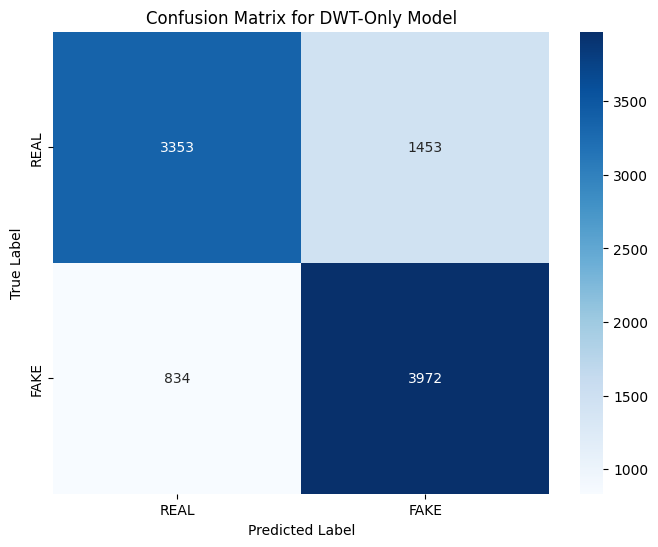


📈 Classification Report:
              precision    recall  f1-score   support

        REAL       0.80      0.70      0.75      4806
        FAKE       0.73      0.83      0.78      4806

    accuracy                           0.76      9612
   macro avg       0.77      0.76      0.76      9612
weighted avg       0.77      0.76      0.76      9612


📤 Upload an image for prediction...


Saving fake.jpg to fake.jpg

✅ Uploaded: fake.jpg

🧠 Prediction: REAL
🎯 Confidence: 83.93%


In [ ]:
!pip install opencv-python tensorflow pywavelets tabulate scikit-learn seaborn matplotlib -q
import os, cv2, numpy as np, tensorflow as tf, pywt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import layers, models
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 🔹 DWT Preprocessing
# ================================
def preprocess_image(img_path, size=64):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- Apply DWT ---
    coeffs2 = pywt.dwt2(gray, 'haar')
    cA, (cH, cV, cD) = coeffs2
    dwt_features = np.sqrt(cH**2 + cV**2 + cD**2)
    dwt_features = cv2.resize(dwt_features, (size, size))
    dwt_features = cv2.normalize(dwt_features, None, 0, 255, cv2.NORM_MINMAX)

    # --- Stack into 3-channel image ---
    stacked = np.stack([dwt_features]*3, axis=-1).astype(np.float32) / 255.0
    return stacked

# ================================
# 🔹 Dataset Load (Corrected)
# ================================
dataset_path = "/content/dataset"  # change if local
paths, labels = [], []

for root, _, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            fpath = os.path.join(root, f)
            if "real" in fpath.lower():
                paths.append(fpath); labels.append(0)
            elif "fake" in fpath.lower():
                paths.append(fpath); labels.append(1)

print(f"📊 Found {len(paths)} images")

# ================================
# 🔹 Train/Test Split (80/20)
# ================================
# Check if any images were found before splitting
if len(paths) == 0:
    print("❌ No images found in the dataset path. Please check the path and try again.")
else:
    X_train_paths, X_test_paths, y_train, y_test = train_test_split(
        paths, labels, test_size=0.2, random_state=42, stratify=labels
    )

    print(f"🧩 Training samples: {len(X_train_paths)}")
    print(f"🧩 Testing samples: {len(X_test_paths)}")

    # ================================
    # 🔹 Data Loading and Preprocessing for Training/Testing
    # (Load and preprocess only the split data)
    # ================================
    print("\n⏳ Loading and preprocessing training images...")
    X_train = [preprocess_image(p) for p in X_train_paths if preprocess_image(p) is not None]
    y_train = [y for i, y in enumerate(y_train) if preprocess_image(X_train_paths[i]) is not None] # Keep corresponding labels

    print("⏳ Loading and preprocessing testing images...")
    X_test = [preprocess_image(p) for p in X_test_paths if preprocess_image(p) is not None]
    y_test = [y for i, y in enumerate(y_test) if preprocess_image(X_test_paths[i]) is not None] # Keep corresponding labels

    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    y_train_cat = tf.keras.utils.to_categorical(y_train, 2)
    y_test_cat  = tf.keras.utils.to_categorical(y_test, 2)

    print("✅ Preprocessed training data shape:", X_train.shape)
    print("✅ Preprocessed testing data shape:", X_test.shape)


    # ================================
    # 🔹 Lightweight CNN
    # ================================
    model = models.Sequential([
        layers.Conv2D(16, (3,3), activation="relu", input_shape=(64,64,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(2, activation="softmax")
    ])

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat),
                          epochs=20, batch_size=64, verbose=1)

    # ================================
    # 🔹 Training Summary (Percentages)
    # ================================
    results = []
    for i in range(len(history.history['accuracy'])):
        results.append([
            i+1,
            f"{history.history['accuracy'][i]*100:.2f}%",
            f"{history.history['val_accuracy'][i]*100:.2f}%",
            round(history.history['loss'][i], 4),
            round(history.history['val_loss'][i], 4)
        ])

    print("\n📊 Training Summary:")
    print(tabulate(results, headers=["Epoch", "Train Acc (%)", "Val Acc (%)", "Train Loss", "Val Loss"], tablefmt="grid"))

    # ================================
    # 🔹 Testing Phase (Accuracy + Metrics)
    # ================================
    print("\n🧪 Evaluating Model on Test Data...")
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    test_acc = accuracy_score(y_test, y_pred_classes)
    print(f"✅ Final Test Accuracy: {test_acc*100:.2f}%")

    print("\n📉 Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_classes)
    print(cm)

    # ================================
    # 🔹 Confusion Matrix Graph
    # ================================
    print("\n📊 Confusion Matrix Plot:")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['REAL', 'FAKE'],
                yticklabels=['REAL', 'FAKE'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for DWT-Only Model')
    plt.show()

    print("\n📈 Classification Report:")
    print(classification_report(y_test, y_pred_classes, target_names=["REAL", "FAKE"]))

    # ================================
    # 🔹 Predict Function
    # ================================
    def predict_image(img_path):
        img = preprocess_image(img_path)
        if img is None:
            print("❌ Invalid image or preprocessing failed.")
            return
        img = np.expand_dims(img, axis=0)
        pred = model.predict(img, verbose=0)[0] # Added verbose=0 to suppress progress bar
        label = "FAKE" if np.argmax(pred) == 1 else "REAL"
        confidence = round(float(np.max(pred))*100, 2)
        print(f"\n🧠 Prediction: {label}\n🎯 Confidence: {confidence}%")

    # ================================
    # 🔹 Input Image (Local / Colab)
    # ================================
    try:
        from google.colab import files
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

    if IN_COLAB:
        print("\n📤 Upload an image for prediction...")
        uploaded = files.upload()
        for filename in uploaded.keys():
            print(f"\n✅ Uploaded: {filename}")
            predict_image(filename)
    else:
        img_path = input("\n📸 Enter image path for prediction: ").strip()
        if not os.path.exists(img_path):
            print("❌ File not found. Please enter a valid image path.")
        else:
            predict_image(img_path)

#lbp

📊 Found 48060 images
🧩 Training samples: 38448
🧩 Testing samples: 9612

⏳ Loading and preprocessing training images...
⏳ Loading and preprocessing testing images...
✅ Preprocessed training data shape: (38448, 64, 64, 3)
✅ Preprocessed testing data shape: (9612, 64, 64, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 130s 212ms/step - accuracy: 0.5076 - loss: 0.6935 - val_accuracy: 0.5003 - val_loss: 0.6920
Epoch 2/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 122s 203ms/step - accuracy: 0.5609 - loss: 0.6803 - val_accuracy: 0.6329 - val_loss: 0.6473
Epoch 3/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 125s 207ms/step - accuracy: 0.6424 - loss: 0.6393 - val_accuracy: 0.6541 - val_loss: 0.6263
Epoch 4/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 138s 201ms/step - accuracy: 0.6677 - loss: 0.6114 - val_accuracy: 0.6517 - val_loss: 0.6226
Epoch 5/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 144s 203ms/step - accuracy: 0.6848 - loss: 0.5924 - val_accuracy: 0.6881 - val_loss: 0.5868
Epoch 6/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 141s 202ms/step - accuracy: 0.6892 - loss: 0.5859 - val_accuracy: 0.6921 - val_loss: 0.5793
Epoch 7/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 145s 208ms/step - accuracy: 0.7008 - loss: 0.5749 - val_accuracy: 0.6676 - val_loss: 0.5995
Epoch 8/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 120s 199ms/step - accuracy: 0.7069 -

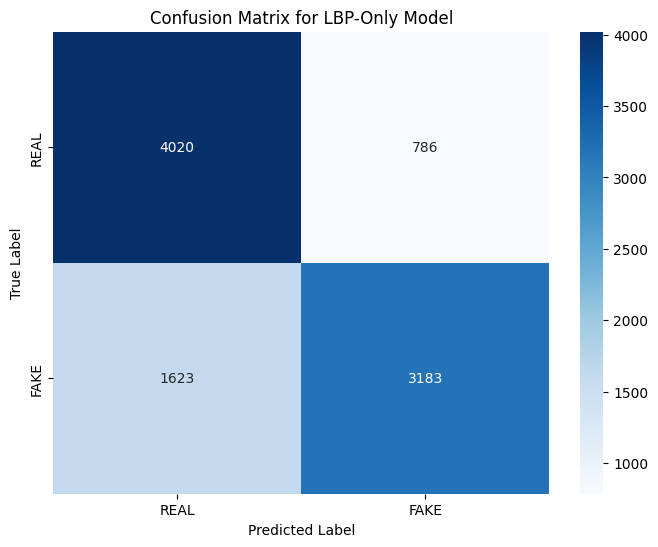


📈 Classification Report (in %):
+---------+-----------------+--------------+----------------+-----------+
| Class   |   Precision (%) |   Recall (%) |   F1-Score (%) |   Support |
+=========+=================+==============+================+===========+
| REAL    |           71.24 |        83.65 |          76.95 |      4806 |
+---------+-----------------+--------------+----------------+-----------+
| FAKE    |           80.2  |        66.23 |          72.55 |      4806 |
+---------+-----------------+--------------+----------------+-----------+

🎯 Overall Accuracy: 74.94%

📤 Upload an image for prediction...


In [ ]:
!pip install opencv-python tensorflow scikit-image tabulate seaborn matplotlib -q

import os, cv2, numpy as np, tensorflow as tf
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras import layers, models
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 🔹 LBP Preprocessing (This function is correct)
# ================================
def preprocess_image(img_path, size=64):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # LBP feature extraction
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    lbp = cv2.normalize(lbp, None, 0, 255, cv2.NORM_MINMAX)
    lbp_img = np.stack([lbp]*3, axis=-1).astype(np.float32) / 255.0
    return lbp_img

# ================================
# 🔹 Dataset Load (Paths only)
# ================================
dataset_path = "/content/dataset"
paths, labels = [], []

for root, _, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            fpath = os.path.join(root, f)
            if "real" in fpath.lower():
                paths.append(fpath); labels.append(0)
            elif "fake" in fpath.lower():
                paths.append(fpath); labels.append(1)

print(f"📊 Found {len(paths)} images")

# ================================
# 🔹 Train/Test Split (On Paths) <-- THIS IS THE FIX
# ================================
# Check if any images were found before splitting
if len(paths) == 0:
    print("❌ No images found in the dataset path. Please check the path and try again.")
else:
    # Split the PATHS, not the loaded data
    X_train_paths, X_test_paths, y_train, y_test = train_test_split(
        paths, labels, test_size=0.2, random_state=42, stratify=labels
    )

    print(f"🧩 Training samples: {len(X_train_paths)}")
    print(f"🧩 Testing samples: {len(X_test_paths)}")

    # ================================
    # 🔹 Data Loading and Preprocessing for Training/Testing <-- NEW SECTION
    # (Load and preprocess only the split data, just like your DWT script)
    # ================================
    print("\n⏳ Loading and preprocessing training images...")
    # List comprehension to build the training set
    X_train = []
    y_train_final = []
    for i, path in enumerate(X_train_paths):
        img = preprocess_image(path)
        if img is not None:
            X_train.append(img)
            y_train_final.append(y_train[i]) # Keep corresponding label

    print("⏳ Loading and preprocessing testing images...")
    # List comprehension to build the test set
    X_test = []
    y_test_final = []
    for i, path in enumerate(X_test_paths):
        img = preprocess_image(path)
        if img is not None:
            X_test.append(img)
            y_test_final.append(y_test[i]) # Keep corresponding label

    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train_final) # This is now y_train
    y_test = np.array(y_test_final)   # This is now y_test (the labels)

    y_train_cat = tf.keras.utils.to_categorical(y_train, 2)
    y_test_cat  = tf.keras.utils.to_categorical(y_test, 2)

    print("✅ Preprocessed training data shape:", X_train.shape)
    print("✅ Preprocessed testing data shape:", X_test.shape)

    # ================================
    # 🔹 Lightweight CNN (No change needed)
    # ================================
    model = models.Sequential([
        layers.Conv2D(16, (3,3), activation="relu", input_shape=(64,64,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(2, activation="softmax")
    ])

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    # ================================
    # 🔹 Train Model (No change needed)
    # ================================
    history = model.fit(
        X_train, y_train_cat,  # Use categorical y_train
        validation_data=(X_test, y_test_cat), # Use categorical y_test
        epochs=20, batch_size=64, verbose=1
    )

    # ================================
    # 🔹 Training Summary (No change needed)
    # ================================
    results = []
    for i in range(len(history.history['accuracy'])):
        results.append([
            i+1,
            f"{history.history['accuracy'][i]*100:.2f}%",
            f"{history.history['val_accuracy'][i]*100:.2f}%",
            round(history.history['loss'][i], 4),
            round(history.history['val_loss'][i], 4)
        ])

    print("\n📊 Training Summary (Accuracy in %):")
    print(tabulate(results, headers=["Epoch", "Train Acc (%)", "Val Acc (%)", "Train Loss", "Val Loss"], tablefmt="grid"))

    # ================================
    # 🔹 Final Test Accuracy (No change needed)
    # ================================
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"\n✅ Final Test Accuracy: {test_acc*100:.2f}%")
    print(f"📉 Final Test Loss: {test_loss:.4f}")

    # ================================
    # 🔹 Confusion Matrix & Classification Report
    # ================================
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(y_test, y_pred_classes) # Use y_test (original 0/1 labels)
    print("\n🧾 Confusion Matrix:")
    print(cm)

    # ================================
    # 🔹 Confusion Matrix Graph (No change needed)
    # ================================
    print("\n📊 Confusion Matrix Plot:")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['REAL', 'FAKE'],
                yticklabels=['REAL', 'FAKE'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for LBP-Only Model')
    plt.show()

    # Use y_test (original 0/1 labels)
    report = classification_report(y_test, y_pred_classes, target_names=["REAL", "FAKE"], output_dict=True)

    # Convert report values to percentage
    print("\n📈 Classification Report (in %):")
    headers = ["Class", "Precision (%)", "Recall (%)", "F1-Score (%)", "Support"]
    rows = []
    for label, metrics in report.items():
        if label in ["REAL", "FAKE"]:
            rows.append([
                label,
                f"{metrics['precision']*100:.2f}",
                f"{metrics['recall']*100:.2f}",
                f"{metrics['f1-score']*100:.2f}",
                int(metrics['support'])
            ])
    overall_acc = report["accuracy"] * 100
    print(tabulate(rows, headers=headers, tablefmt="grid"))
    print(f"\n🎯 Overall Accuracy: {overall_acc:.2f}%")

    # ================================
    # 🔹 Predict Function (No change needed)
    # ================================
    def predict_image(img_path):
        img = preprocess_image(img_path)
        if img is None:
            print("❌ Invalid image.")
            return
        img = np.expand_dims(img, axis=0)
        pred = model.predict(img, verbose=0)[0]
        label = "FAKE" if np.argmax(pred) == 1 else "REAL"
        confidence = round(float(np.max(pred))*100, 2)
        print(f"\n🧠 Prediction: {label}\n🎯 Confidence: {confidence}%")

    # ================================
    # 🔹 Take Input Image (No change needed)
    # ================================
    try:
        from google.colab import files
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

    if IN_COLAB:
        print("\n📤 Upload an image for prediction...")
        uploaded = files.upload()
        for filename in uploaded.keys():
            print(f"\n✅ Uploaded: {filename}")
            predict_image(filename)
    else:
        img_path = input("\n📸 Enter image path for prediction: ").strip()
        if not os.path.exists(img_path):
            print("❌ File not found. Please enter a valid image path.")
        else:
            predict_image(img_path)

#dwt+lbp

#dwt+lbp(from prashanth)

📊 Found 48060 image paths

⏳ Processing test set into memory...
✅ Test set processed.
🧩 Training samples: 38448
🧩 Testing samples: 9612


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🔥 Starting model training for 20 epochs...
Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 82s 252ms/step - accuracy: 0.6533 - loss: 0.6083 - val_accuracy: 0.8089 - val_loss: 0.4048
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 73s 243ms/step - accuracy: 0.8217 - loss: 0.3886 - val_accuracy: 0.8679 - val_loss: 0.2946
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 71s 236ms/step - accuracy: 0.8794 - loss: 0.2793 - val_accuracy: 0.8902 - val_loss: 0.2522
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 69s 229ms/step - accuracy: 0.9029 - loss: 0.2313 - val_accuracy: 0.8984 - val_loss: 0.2335
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 69s 228ms/step - accuracy: 0.9184 - loss: 0.1978 - val_accuracy: 0.9007 - val_loss: 0.2288
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 68s 228ms/step - accuracy: 0.9266 - loss: 0.1745 - val_accuracy: 0.9045 - val_loss: 0.2181
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 72s 239ms/step - accuracy: 0.9388 - loss: 0.1517 - val_accuracy: 0.9112 - val_loss: 0.2222
Epoch 8/20
301/301 ━━━━━━━━━━━━━━━━━━━━

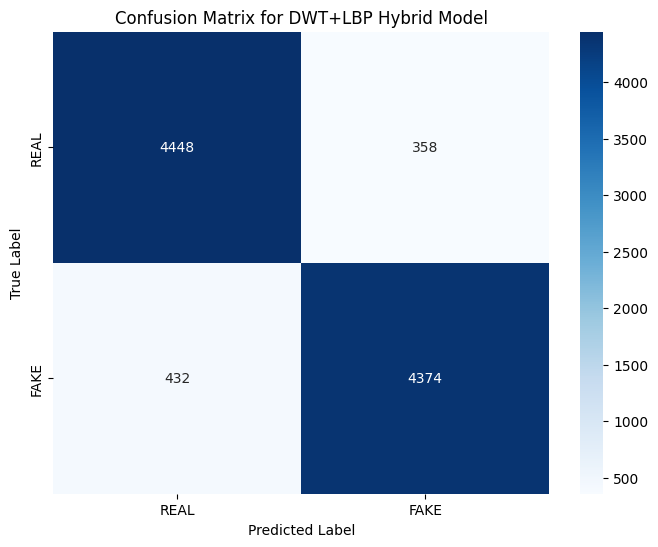


📈 Classification Report:
              precision    recall  f1-score   support

        REAL       0.91      0.93      0.92      4806
        FAKE       0.92      0.91      0.92      4806

    accuracy                           0.92      9612
   macro avg       0.92      0.92      0.92      9612
weighted avg       0.92      0.92      0.92      9612


📤 Upload an image for prediction...


Saving sharon.jpg to sharon.jpg

✅ Uploaded: sharon.jpg

🧠 Prediction: REAL
🎯 Confidence: 100.0%


In [ ]:
!pip install opencv-python scikit-image tensorflow pywavelets tabulate scikit-learn seaborn matplotlib -q
import os, cv2, numpy as np, tensorflow as tf, pywt
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import layers, models
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil # Used for generator steps

# -----------------------------
# 🔹 DWT + LBP Preprocessing
# (This function is unchanged)
# -----------------------------
def preprocess_image(img_path, size=64):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- DWT ---
    coeffs2 = pywt.dwt2(gray, 'haar')
    cA, (cH, cV, cD) = coeffs2
    dwt_features = np.sqrt(cH**2 + cV**2 + cD**2)
    dwt_features = cv2.resize(dwt_features, (size, size))
    dwt_features = cv2.normalize(dwt_features, None, 0, 255, cv2.NORM_MINMAX)

    # --- LBP ---
    lbp = local_binary_pattern(gray, 8, 1, method="uniform")
    lbp = cv2.normalize(lbp, None, 0, 255, cv2.NORM_MINMAX)

    # --- Feature Fusion ---
    # Stack Grayscale, DWT, and LBP as 3 channels
    stacked = np.dstack([gray, dwt_features, lbp]).astype(np.float32) / 255.0
    return stacked

# ==================================
# 🔹 Load Paths Only
# ==================================
def load_dataset_paths(dataset_path):
    paths, labels = [], []
    for root, _, files in os.walk(dataset_path):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                fpath = os.path.join(root, f)
                if "real" in fpath.lower():
                    paths.append(fpath); labels.append(0)
                elif "fake" in fpath.lower():
                    paths.append(fpath); labels.append(1)

    print(f"📊 Found {len(paths)} image paths")
    return np.array(paths), np.array(labels)

# ==================================
# 🔹 Data Generator
# ==================================
def data_generator(image_paths, image_labels, batch_size=32, size=64):
    num_samples = len(image_paths)
    while True:
        # Shuffle data for each epoch
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        image_paths = image_paths[indices]
        image_labels = image_labels[indices]

        for i in range(0, num_samples, batch_size):
            batch_paths = image_paths[i:i + batch_size]
            batch_labels = image_labels[i:i + batch_size]

            imgs, labels = [], []
            for fpath, label in zip(batch_paths, batch_labels):
                processed = preprocess_image(fpath, size)
                if processed is not None:
                    imgs.append(processed)
                    labels.append(label)

            if imgs:
                yield np.array(imgs), tf.keras.utils.to_categorical(labels, num_classes=2)

# -----------------------------
# 🔹 Load Paths and Split (80/20)
# -----------------------------
# Assuming dataset is already at /content/dataset from previous runs
dataset_path = "/content/dataset"
if not os.path.exists(dataset_path):
    print("❌ Dataset not found. Please run the unzip code block first.")
else:
    paths, labels = load_dataset_paths(dataset_path)

    train_paths, test_paths, y_train_labels, y_test_labels = train_test_split(
        paths, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # -----------------------------
    # 🔹 Create Generators & Test Set
    # -----------------------------
    BATCH_SIZE = 128 # You can tune this (e.g., 64, 128)

    # Create generators for training
    train_gen = data_generator(train_paths, y_train_labels, batch_size=BATCH_SIZE, size=64)
    train_steps = ceil(len(train_paths) / BATCH_SIZE)

    # For evaluation, we process the smaller test set into RAM
    print("\n⏳ Processing test set into memory...")
    X_test, y_test = [], []
    for fpath, label in zip(test_paths, y_test_labels):
        processed = preprocess_image(fpath, 64)
        if processed is not None:
            X_test.append(processed)
            y_test.append(label)

    X_test = np.array(X_test)
    y_test = np.array(y_test)
    y_test_cat = tf.keras.utils.to_categorical(y_test, 2)
    print("✅ Test set processed.")

    print(f"🧩 Training samples: {len(train_paths)}")
    print(f"🧩 Testing samples: {len(test_paths)}")


    # -----------------------------
    # 🔹 CNN Model
    # -----------------------------
    # A slightly deeper model for the more complex fused features
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation="relu", input_shape=(64,64,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(2, activation="softmax")
    ])

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    # model.summary() <-- This line has been removed as requested

    # -----------------------------
    # 🔹 Train Model using Generator
    # -----------------------------
    print("\n🔥 Starting model training for 20 epochs...")
    history = model.fit(
        train_gen,
        validation_data=(X_test, y_test_cat), # We use the X_test/y_test arrays
        epochs=20, # <-- Set to 20 epochs
        steps_per_epoch=train_steps,
        verbose=1
    )
    print("✅ Model training complete.")

    # -----------------------------
    # 🔹 Epoch-wise Training Summary
    # -----------------------------
    results = []
    for i in range(len(history.history['accuracy'])):
        results.append([
            i+1,
            f"{history.history['accuracy'][i]*100:.2f}%",
            f"{history.history['val_accuracy'][i]*100:.2f}%",
            round(history.history['loss'][i], 4),
            round(history.history['val_loss'][i], 4)
        ])

    print("\n📊 Training Summary:")
    print(tabulate(
        results,
        headers=["Epoch", "Train Acc (%)", "Val Acc (%)", "Train Loss", "Val Loss"],
        tablefmt="grid"
    ))

    # -----------------------------
    # 🔹 Final Test Accuracy + Metrics
    # -----------------------------
    print("\n🧪 Evaluating Model on Test Data...")
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    final_test_acc = accuracy_score(y_test, y_pred_classes)
    print(f"✅ Final Test Accuracy: {final_test_acc*100:.2f}%\n")

    print("📉 Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_classes)
    print(cm)

    # -----------------------------
    # 🔹 Confusion Matrix Plot
    # -----------------------------
    print("\n📊 Confusion Matrix Plot:")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['REAL', 'FAKE'],
                yticklabels=['REAL', 'FAKE'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for DWT+LBP Hybrid Model')
    plt.show()

    print("\n📈 Classification Report:")
    print(classification_report(y_test, y_pred_classes, target_names=["REAL", "FAKE"]))

    # -----------------------------
    # 🔹 Predict Function
    # -----------------------------
    def predict_image(img_path):
        img = preprocess_image(img_path)
        if img is None:
            print("❌ Invalid image.")
            return
        img = np.expand_dims(img, axis=0)
        pred = model.predict(img, verbose=0)[0]
        label = "FAKE" if np.argmax(pred) == 1 else "REAL"
        confidence = round(float(np.max(pred))*100, 2)
        print(f"\n🧠 Prediction: {label}\n🎯 Confidence: {confidence}%")

    # -----------------------------
    # 🔹 Input Image (Local / Colab)
    # -----------------------------
    try:
        from google.colab import files
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

    if IN_COLAB:
        print("\n📤 Upload an image for prediction...")
        uploaded = files.upload()
        for filename in uploaded.keys():
            print(f"\n✅ Uploaded: {filename}")
            predict_image(filename)
    else:
        img_path = input("\n📸 Enter image path for prediction: ").strip()
        if not os.path.exists(img_path):
            print("❌ File not found. Please enter a valid image path.")
        else:
            predict_image(img_path)